In [25]:
%%HTML 
<style>
body {
    max-width: 100%;
    margin-left: 5%;
    margin-right: 40%;
}
</style>

# Preamble

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson
from cycler import cycler


# --- Scientific Presentation Style ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2.5,
    'figure.figsize': (10, 6),
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "legend.fontsize": 12,
    "legend.frameon": False,
})

muted_tab10 = [
    "#73A0BD",  # blue
    "#EEA461",  # orange
    "#7AB672",  # green
    "#D77470",  # red
    "#B397C2",  # purple
    "#AF8E83",  # brown
    "#DEA0C4",  # pink
    "#A8A49F",  # gray
    "#C9C66C",  # olive
    "#6EC7CB",  # cyan
]

plt.rcParams["axes.prop_cycle"] = cycler(color = muted_tab10)


In [27]:
### SETUP ###

# physical constants
c       = 3e8                    # speed of light [m/s]
k_B     = 8.617333262145e-5      # Boltzmann constant [eV/K]
hbar    = 6.582119569e-16        # Reduced Planck constant [eV*s]
m_e     = 5.485e-4               # electron mass [eV*(s/m)^2]

# material constants
E_F     = 5.0                    # Chemical potential [eV]
T_F     = E_F/k_B                # Fermi temperature [K]

# system constants
T_e     = 300                    # electron system temperature [K]
E_L     = 2.25                   # pump photon energy [eV]
EF_L    = 5e10                   # pump field strength [V^2/m^2]
EF_sat  = 1e13                   # saturation field [V^2/m^2]
delta_E = (EF_L/EF_sat)**2       # non-equilibrium factor [a.u.]

# Helper Functions

In [28]:
# Relative Error
def rel_error(ref, test):
    ref = np.asarray(ref)
    test = np.asarray(test)
    rel = np.abs((ref - test) / ref)

    return np.clip(rel, 1e-16, 1.0)

# Bose-Einstein distribution
def n_BE(hw):
    beta = 1 / (k_B * T_e)
    return 1 / np.expm1(beta * hw)

# Black Body Spectrum
def E_BB(hw):
    return hw * n_BE(hw)

# Photonic Contribution to Emission
def I_ph(hw):
    '''
    photonic density of states
    
    :param hw: emission (photon) energy [ev]
    '''
    return

# Main Functions

<!-- **Electronic density of states**

$$ \rho_e(\mathcal{E}) = \frac{{m_e}^{3/2}}{\pi^2\hbar^3}\sqrt{2\mathcal{E}} $$

**Fermi-Dirac distribution**

$$ f^{T}(\mathcal{E}) = \frac{1}{\exp\Big(\frac{\mathcal{E}-\mu}{k_{B}T}\Big)+1} $$

**Chemical potential (first-order in $T/T_F$)**

$$ \mu(T) = \mathcal{E}_{\scriptsize F}\left[1- \frac{\pi^{2}}{12}\left( \frac{T}{T_{\scriptsize F}} \right)^{2}\right] $$ -->



In [29]:
# parabolic conduction band eDOS
def g_c(E):
    return ( ((m_e)**(3/2)) / ((np.pi**2)*(hbar**3)) )*np.sqrt(2*E)

def g_const(E):
    return g_c(E_F)

# def g_c_X(E)
# def g_c_L(E)
# def g_v_X(E)
# def g_v_L(E)

# Thermal distribution
def f_T(E):
    C = ((np.pi**2)/12)
    # chemical potential for fermi gas with T << T_F in 3D
    mu = E_F*( 1 - C*((T_e/T_F)**2))
    return 1 / (np.exp((E - mu) / (k_B * T_e)) + 1)

# Steady-state distribution
def f_S(E):
    A = f_T(E - E_L) * (1 - f_T(E))
    B = f_T(E) * (1 - f_T(E + E_L))
    return f_T(E) + delta_E*(A-B)

# Stable thermal factor (avoids 1 - f cancellation)
def F_T(E, hw):
    beta = 1 / (k_B * T_e)
    C = ((np.pi**2)/12)
    mu = E_F*( 1 - C*((T_e/T_F)**2))
    a1 = beta * (E + hw - mu)
    a2 = beta * (E - mu)
    return np.exp(a2 - np.logaddexp(0.0, a2) - np.logaddexp(0.0, a1))

# Statistical factor
def F(E, hw, dist):
    '''
    Statistical Factor
    
    :param E:    energy integration variable [ev]
    :param hw:   emission energy [ev]
    :param dist: electronic distribution f(E)
    '''
    if dist is f_T:
        return F_T(E, hw)
    return dist(E + hw) * (1 - dist(E))

# Jacobian
def J(E, hw, eDOS1, eDOS2):
    '''
    Jacobian - determined by dispersion relation
    
    :param E:     energy integration variable [ev]
    :param hw:    emission energy [ev]
    :param eDOS1: initial electronic density of states g(E)
    :param eDOS1: final electronic density of states g(E)
    '''
    return eDOS1(E + hw) * eDOS2(E)

# Integrand
def integrand(E, hw, dist, eDOS1, eDOS2):
    '''
    Integrand
    
    :param E:    energy integration variable [ev]
    :param hw:   emission energy [ev]
    :param dist: electronic density of states g(E)
                 determines whether we're in a thermal,
                 steady-state or pulsed scenario.
    :param eDOS: electronic density of states g(E)
                 depends on whether we're using a
                 parabolic, quadratic, intra or interband transitions
    '''
    return F(E, hw, dist) * J(E, hw, eDOS1, eDOS2)

# Emission
# Ei = Ef + hw
# Ei - Ef - hw   = 0
# Ei - (Ef + hw) = 0

def I_e(E_list, hw_list, dist, eDOS1, eDOS2):
    '''
    electronic contribution to emission
    
    :param E_list:  integration interval
    :param hw_list: hw points over which the integral is computed
    '''
    result = []
    for hw in hw_list:
        integral = simpson(integrand(E_list, hw, dist, eDOS1, eDOS2), E_list)
        result.append(integral)

    return result

# exact thermal intraband emission constant eDOS
def I_e_exact_T(hw_list, eDOS):
    beta = 1 / (k_B * T_e)
    mu = E_F*( 1 - ((np.pi**2)/12)*((T_e/T_F)**2))
    A = (eDOS(E_F)**2)  * n_BE(hw_list)
    log1pa = np.logaddexp(0.0, -beta * mu)
    log1pb = np.logaddexp(0.0, beta * (hw_list - mu))
    return A * (hw_list + (log1pa - log1pb) / beta)

# approximaete thermal intraband emission constant eDOS
def I_e_approx_T(hw_list, eDOS):
    return (eDOS(E_F)**2) * hw_list * n_BE(hw_list)

# approximaete steady-state intraband emission constant eDOS
def I_e_approx_S(hw_list, eDOS):
    A = 2*E_BB(hw_list - E_L)
    B = -2*E_BB(hw_list - E_L) + E_BB(hw_list - 2*E_L)
    return (eDOS(E_F)**2) * (E_BB(hw_list) + delta_E*A + delta_E*delta_E*B)


# Numeric Convergence
## Step Size Convergence

<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
/var/folders/8_/lb82j87n40q1pn140s68mgz80000gn/T/ipykernel_52449/3630007296.py:23: SyntaxWarning: invalid escape sequence '\l'
  axes[i].set_ylabel('$\log_{10}(\delta_{rel})$')


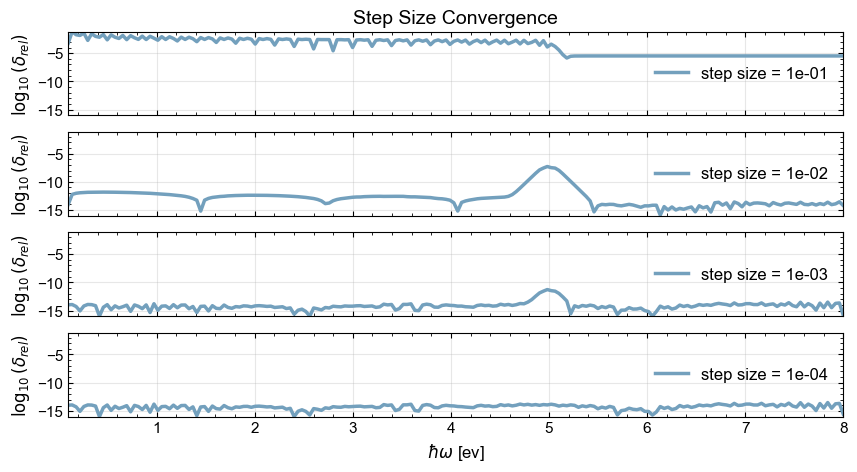

In [30]:
hw_list = np.linspace(0.1, 8.0, 200)
I_intra_exact_T = I_e_exact_T(hw_list, g_const)
step_sizes = [1e-1, 1e-2, 1e-3, 1e-4]
fig, axes = plt.subplots(nrows=len(step_sizes), ncols=1, figsize=(10.0, 5.0), sharex=True)

all_log_err = []
for step_size in step_sizes:
    E_list = np.arange(0.0, 10.0, step_size)
    I_intra_parabolic_T = I_e(E_list, hw_list, f_T, g_const, g_const)
    relative_error = rel_error(I_intra_exact_T, I_intra_parabolic_T)
    all_log_err.append(np.log10(relative_error))

finite_vals = np.concatenate([arr[np.isfinite(arr)] for arr in all_log_err])
ymin = finite_vals.min()
ymax = finite_vals.max()

for i, step_size in enumerate(step_sizes):
    axes[i].plot(hw_list, all_log_err[i], label=f'step size = {step_size:.0e}')
    axes[i].set_ylim(ymin, ymax)
    axes[i].set_xlim(hw_list[0], hw_list[-1])
    axes[i].legend(loc = 'right')
    axes[i].set_facecolor("none")
    axes[i].set_ylabel('$\log_{10}(\delta_{rel})$')

axes[-1].set_xlabel(r'$\hbar\omega$ [ev]')
axes[0].set_title('Step Size Convergence')

fig.patch.set_alpha(0)
plt.savefig("/Users/ben/Projects/metal_photoluminescence/docs/figures/step_size_convergence.png", dpi=300, transparent=True, bbox_inches="tight")

## Integration Interval Convergence

<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
/var/folders/8_/lb82j87n40q1pn140s68mgz80000gn/T/ipykernel_52449/2018468201.py:23: SyntaxWarning: invalid escape sequence '\l'
  axes[i].set_ylabel('$\log_{10}(\delta_{rel})$')


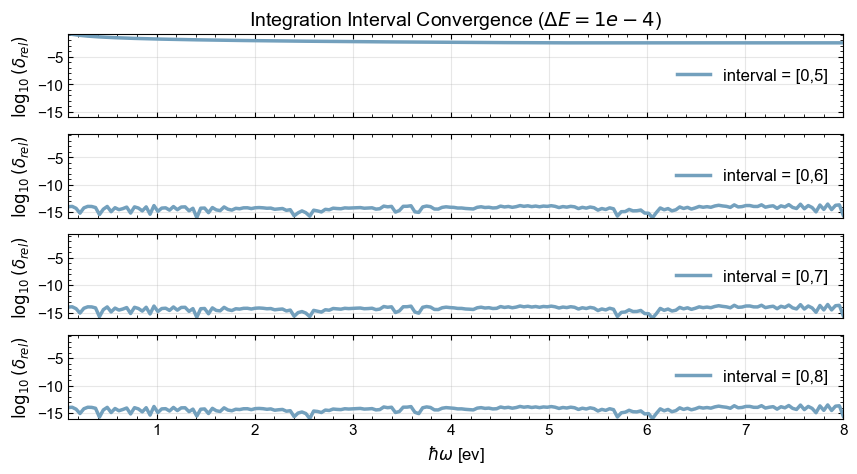

In [31]:
hw_list = np.linspace(0.1, 8.0, 200)
I_intra_exact_T = I_e_exact_T(hw_list, g_const)
interval_length = [5,6,7,8]
fig, axes = plt.subplots(nrows=len(interval_length), ncols=1, figsize=(10.0, 5.0), sharex=True)

all_log_err = []
for L in interval_length:
    E_list = np.arange(0.0, L, 1e-4)
    I_intra_parabolic_T = I_e(E_list, hw_list, f_T, g_const, g_const)
    relative_error = rel_error(I_intra_exact_T, I_intra_parabolic_T)
    all_log_err.append(np.log10(relative_error))

finite_vals = np.concatenate([arr[np.isfinite(arr)] for arr in all_log_err])
ymin = finite_vals.min()
ymax = finite_vals.max()

for i, L in enumerate(interval_length):
    axes[i].plot(hw_list, all_log_err[i], label=f'interval = [0,{L}]')
    axes[i].set_ylim(ymin, ymax)
    axes[i].set_xlim(hw_list[0], hw_list[-1])
    axes[i].legend(loc = 'right')
    axes[i].set_facecolor("none")
    axes[i].set_ylabel('$\log_{10}(\delta_{rel})$')

axes[-1].set_xlabel(r'$\hbar\omega$ [ev]')
axes[0].set_title(r'Integration Interval Convergence ($\Delta E = 1e-4$)')

fig.patch.set_alpha(0)
plt.savefig("/Users/ben/Projects/metal_photoluminescence/docs/figures/interval_length_convergence.png", dpi=300, transparent=True, bbox_inches="tight")

## Analytic Approximations VS Numeric Constant eDOS

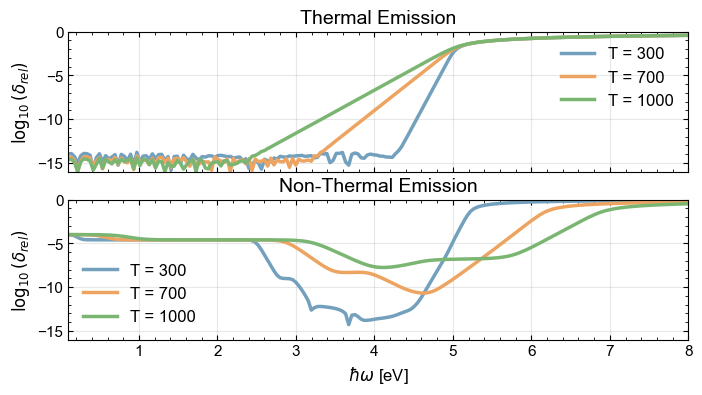

In [32]:
E_list = np.linspace(0.0,10.0,100000)
hw_list = np.linspace(0.1, 8.0, 200)

fig, axes = plt.subplots(ncols=1, nrows=2, figsize=(8.0, 4.0), sharex=True)
for T_e in [300, 700, 1000]:
    I_intra_parabolic_T = I_e(E_list, hw_list, f_T, g_const, g_const)
    I_intra_parabolic_S = I_e(E_list, hw_list, f_S, g_const, g_const)
    I_intra_approx_T    = I_e_approx_T(hw_list, g_const)
    I_intra_approx_S    = I_e_approx_S(hw_list, g_const)

    rel_T = rel_error(I_intra_approx_T, I_intra_parabolic_T)
    rel_S = rel_error(I_intra_approx_S, I_intra_parabolic_S)
    axes[0].plot(hw_list, np.log10(rel_T), label = f'T = {T_e}')
    axes[1].plot(hw_list, np.log10(rel_S), label = f'T = {T_e}')

for ax in axes:
    ax.set_xlim(hw_list[0], hw_list[-1])
    ax.set_ylim(-16,0)
    ax.legend()
ax.set_xlabel(r'$\hbar\omega$ [eV]')

# fig.suptitle(r'Analytic Approximations')
axes[0].set(title = 'Thermal Emission', ylabel = '$\\log_{10}(\\delta_{rel})$');
axes[1].set(title = 'Non-Thermal Emission', ylabel = '$\\log_{10}(\\delta_{rel})$');

fig.patch.set_alpha(0)
plt.savefig("/Users/ben/Projects/metal_photoluminescence/docs/figures/analytic_approximations.png", dpi=300, transparent=True, bbox_inches="tight")

/var/folders/8_/lb82j87n40q1pn140s68mgz80000gn/T/ipykernel_52449/1023486282.py:18: RuntimeWarning: overflow encountered in exp
  return 1 / (np.exp((E - mu) / (k_B * T_e)) + 1)


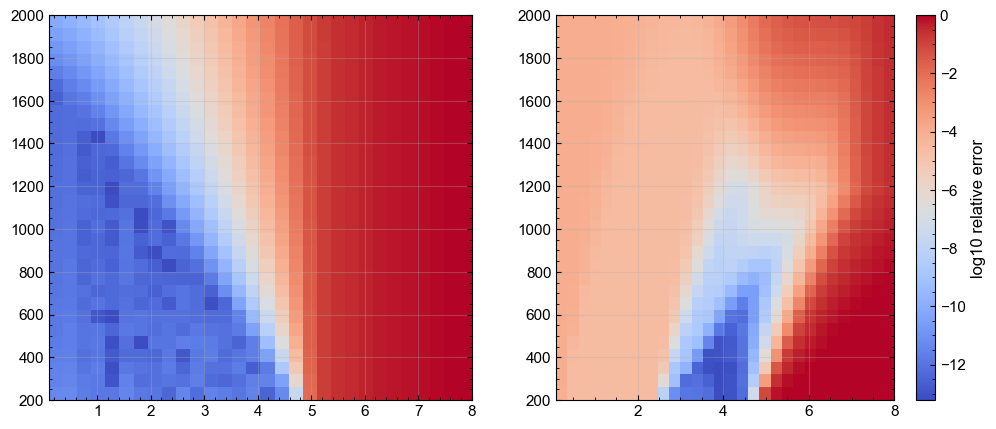

In [54]:
N = 30
im_T = np.zeros((N, N))
im_S = np.zeros((N, N))
hw_list = np.linspace(0.1, 8.0, N)
T_e_list = np.linspace(200, 2000, N)

for i, T_e in enumerate(T_e_list):
    I_ref_T = np.array(I_e(E_list, hw_list, f_T, g_const, g_const))
    I_approx_T = I_e_approx_T(hw_list, g_const)
    I_ref_S = np.array(I_e(E_list, hw_list, f_S, g_const, g_const))
    I_approx_S = I_e_approx_S(hw_list, g_const)

    rel_T = np.log10(np.clip(rel_error(I_ref_T, I_approx_T), 1e-16, None))
    rel_S = np.log10(np.clip(rel_error(I_ref_S, I_approx_S), 1e-16, None))
    im_T[i, :] = rel_T
    im_S[i, :] = rel_S

fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(12.0, 5.0))
m0 = axes[0].imshow(
    im_T, origin="lower", aspect="auto",
    extent=[hw_list[0], hw_list[-1], T_e_list[0], T_e_list[-1]],
    cmap="coolwarm"
)
m1 = axes[1].imshow(
    im_S, origin="lower", aspect="auto",
    extent=[hw_list[0], hw_list[-1], T_e_list[0], T_e_list[-1]],
    cmap="coolwarm"
)
# fig.colorbar(m0, ax=axes[0], label="log10 relative error")
fig.colorbar(m1, ax=axes[1], label="log10 relative error")


# Variable VS Constant eDOS

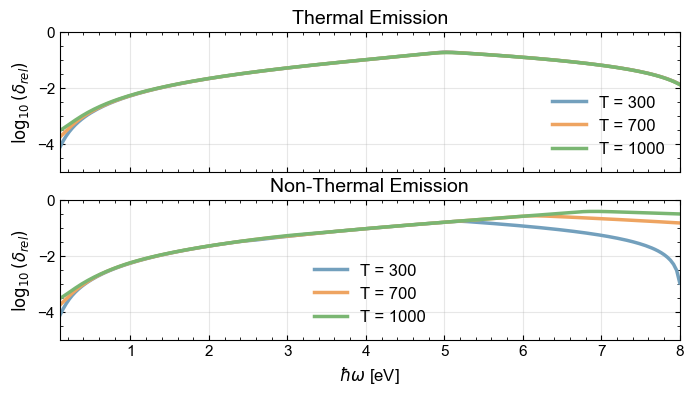

In [ ]:
fig, axes = plt.subplots(ncols=1, nrows=2, figsize=(8.0, 4.0), sharex=True)
for T_e in [300, 700, 1000]:
    I_intra_const_T = I_e(E_list, hw_list, f_T, g_const, g_const)
    I_intra_const_S = I_e(E_list, hw_list, f_S, g_const, g_const)
    I_intra_var_T   = I_e(E_list, hw_list, f_T, g_c, g_c)
    I_intra_var_S   = I_e(E_list, hw_list, f_S, g_c, g_c)

    rel_T = rel_error(I_intra_var_T, I_intra_const_T)
    rel_S = rel_error(I_intra_var_S, I_intra_const_S)
    axes[0].plot(hw_list, np.log10(rel_T), label = f'T = {T_e}')
    axes[1].plot(hw_list, np.log10(rel_S), label = f'T = {T_e}')

for ax in axes:
    ax.set_xlim(hw_list[0], hw_list[-1])
    ax.set_ylim(-5,0)
    ax.legend()
ax.set_xlabel(r'$\hbar\omega$ [eV]')

# fig.suptitle(r'Constant eDOS approximation')

axes[0].set(title = 'Thermal Emission', ylabel = '$\\log_{10}(\\delta_{rel})$');
axes[1].set(title = 'Non-Thermal Emission', ylabel = '$\\log_{10}(\\delta_{rel})$');

fig.patch.set_alpha(0)
plt.savefig("/Users/ben/Projects/metal_photoluminescence/docs/figures/constant_eDOS_approximation.png", dpi=300, transparent=True, bbox_inches="tight")

In [ ]:
def G(E1, E2, hw, sigma):
    """Normalized Gaussian approximation of Dirac Delta."""
    return (1.0 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-0.5 * ((E1 - E2 - hw) / sigma) ** 2)

# Stable thermal factor (avoids 1 - f cancellation)
def F_T2(E1, E2):
    beta = 1 / (k_B * T_e)
    mu = E_F*( 1 - ((np.pi**2)/12)*((T_e/T_F)**2))
    a1 = beta * (E1 - mu)
    a2 = beta * (E2 - mu)
    return np.exp(a2 - np.logaddexp(0.0, a2) - np.logaddexp(0.0, a1))

def I_e_exact_T_trunc(hw_list, E_list, eDOS, E_bounds=None):
    E2_vals = np.asarray(E_list)
    E_min   = E2_vals.min()
    E_max   = E2_vals.max()


    g2 = eDOS(E_F) ** 2
    results = []
    for hw in hw_list:
        E2_max = E_max - hw
        if E2_max <= E_min:
            results.append(0.0)
            continue

        mask = (E2_vals >= E_min) & (E2_vals <= E2_max)
        E2 = E2_vals[mask]
        E1 = E2 + hw
        integrand = g2 * F_T2(E1, E2)
        results.append(simpson(integrand, x=E2))

    return np.array(results)

def integrand_delta(E1, E2, hw, sigma):
    return (g_c(E_F) ** 2) * G(E1, E2, hw, sigma) * F_T2(E1, E2)

def I_e_delta_T(hw_list, sigma):
    result = []
    for hw in hw_list:
        E1 = E_list[:, None]
        E2 = E_list[None, :]
        integrand = integrand_delta(E1, E2, hw,  sigma)

        inner = simpson(integrand, E_list, axis=1)  # integrate over E2
        outer = simpson(inner, E_list, axis=0)      # integrate over E1

        result.append(outer)
    
    return result

sigma = 0.1
hw_list = np.linspace(0.1, 8.0, 100)
E_list = np.linspace(0.0,10.0,1000)
I_exact = I_e_exact_T(hw_list, g_const)
I_exact_trunc = I_e_exact_T_trunc(hw_list, E_list, g_const)
I_delta = I_e_delta_T(hw_list, sigma)

In [ ]:
def I_e_delta_optimized(hw_list, sigma, N, M, E_bounds=(0.0, 10.0), E1_vals=None):
    """Vectorized E1/E2 integral with explicit bounds on both variables."""

    E_min, E_max = E_bounds

    # Grid for u = E1 - E2 - hw (local variable centered on Gaussian)
    u_vals = np.linspace(-M * sigma, M * sigma, int(M * N) + 1)

    if E1_vals is None:
        step_size = (2 * sigma) / N
        n_E1 = int(np.round((E_max - E_min) / step_size)) + 1
        E1_vals = np.linspace(E_min, E_max, n_E1)
    else:
        E1_vals = np.asarray(E1_vals)
        E_min = E1_vals.min()
        E_max = E1_vals.max()

    # Precompute Gaussian (depends only on u)
    G_u = (1.0 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-0.5 * (u_vals / sigma)**2)
    dos_factor = g_c(E_F) ** 2

    results = []
    for hw in hw_list:
        E1_grid = E1_vals[:, None]
        E2_grid = E1_grid - hw - u_vals[None, :]

        integrand = dos_factor * G_u[None, :] * F_T2(E1_grid, E2_grid)
        mask = (E2_grid >= E_min) & (E2_grid <= E_max)
        integrand = np.where(mask, integrand, 0.0)

        inner_integral = simpson(integrand, x=u_vals, axis=1)
        total_integral = simpson(inner_integral, x=E1_vals)
        results.append(total_integral)

    return np.array(results)

def I_e_sigma_uv(hw_list, sigma, E2_vals, M=10, N=200, E_bounds=None):
    """Gaussian-smeared delta integral using E2 and u variables."""
    E2_vals = np.asarray(E2_vals)
    if E_bounds is None:
        E_min = E2_vals.min()
        E_max = E2_vals.max()
    else:
        E_min, E_max = E_bounds

    u_vals = np.linspace(-M * sigma, M * sigma, int(M * N) + 1)
    G_u = (1.0 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-0.5 * (u_vals / sigma)**2)
    g2 = g_c(E_F) ** 2

    results = []
    for hw in hw_list:
        E2_grid = E2_vals[:, None]
        E1_grid = E2_grid + hw + u_vals[None, :]

        integrand = g2 * G_u[None, :] * F_T2(E1_grid, E2_grid)
        mask = (E1_grid >= E_min) & (E1_grid <= E_max)
        integrand = np.where(mask, integrand, 0.0)

        inner = simpson(integrand, x=u_vals, axis=1)
        results.append(simpson(inner, x=E2_vals))

    return np.array(results)

def I_e_delta_uv(hw_list, E2_vals, E_bounds=None):
    """Delta-limit integral on the same E2 grid as I_e_sigma_uv."""
    E2_vals = np.asarray(E2_vals)
    if E_bounds is None:
        E_min = E2_vals.min()
        E_max = E2_vals.max()
    else:
        E_min, E_max = E_bounds

    g2 = g_c(E_F) ** 2
    results = []
    for hw in hw_list:
        E1 = E2_vals + hw
        mask = (E1 >= E_min) & (E1 <= E_max)
        integrand = g2 * F_T2(E1[mask], E2_vals[mask])
        results.append(simpson(integrand, x=E2_vals[mask]))

    return np.array(results)


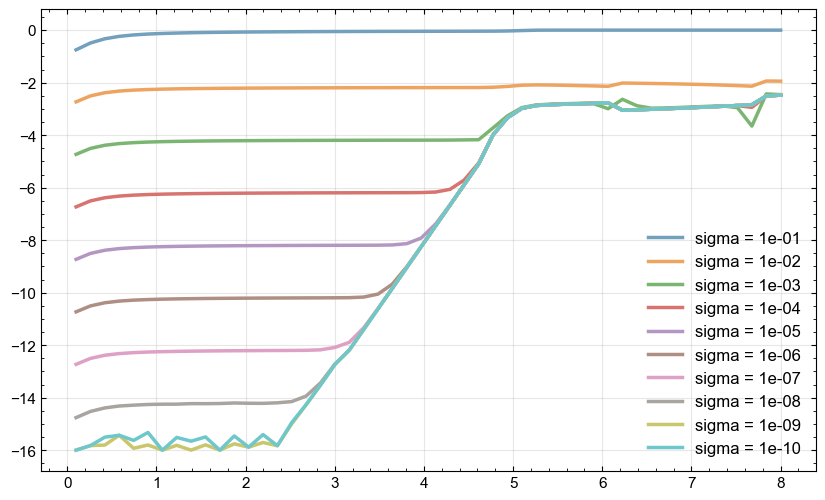

In [ ]:
hw_list = np.linspace(0.1, 8.0, 50)
E2_vals = E_list
I_delta_ref = I_e_delta_uv(hw_list, E2_vals)
for sigma in [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9, 1e-10]:
    I_sigma = I_e_sigma_uv(hw_list, sigma, E2_vals, M=10, N=200)
    plt.plot(hw_list, np.log10(rel_error(I_delta_ref, I_sigma)), label = f'sigma = {sigma:.0e}')
plt.legend()

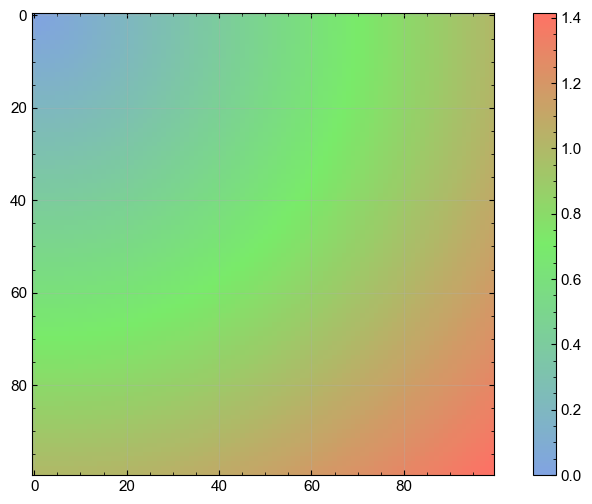

In [41]:
import numpy as np
import matplotlib.colors as mcolors

def _srgb_to_linear(c):
    c = np.asarray(c)
    return np.where(c <= 0.04045, c / 12.92, ((c + 0.055) / 1.055) ** 2.4)

def _linear_to_srgb(c):
    c = np.asarray(c)
    return np.where(c <= 0.0031308, 12.92 * c, 1.055 * (c ** (1/2.4)) - 0.055)

# OKLab conversions (Björn Ottosson)
def _linear_srgb_to_oklab(rgb_lin):
    r, g, b = rgb_lin[..., 0], rgb_lin[..., 1], rgb_lin[..., 2]
    l = 0.4122214708*r + 0.5363325363*g + 0.0514459929*b
    m = 0.2119034982*r + 0.6806995451*g + 0.1073969566*b
    s = 0.0883024619*r + 0.2817188376*g + 0.6299787005*b
    l_, m_, s_ = np.cbrt(l), np.cbrt(m), np.cbrt(s)
    L = 0.2104542553*l_ + 0.7936177850*m_ - 0.0040720468*s_
    a = 1.9779984951*l_ - 2.4285922050*m_ + 0.4505937099*s_
    b = 0.0259040371*l_ + 0.7827717662*m_ - 0.8086757660*s_
    return np.stack([L, a, b], axis=-1)

def _oklab_to_linear_srgb(lab):
    L, a, b = lab[..., 0], lab[..., 1], lab[..., 2]
    l_ = L + 0.3963377774*a + 0.2158037573*b
    m_ = L - 0.1055613458*a - 0.0638541728*b
    s_ = L - 0.0894841775*a - 1.2914855480*b
    l, m, s = l_**3, m_**3, s_**3
    r = +4.0767416621*l - 3.3077115913*m + 0.2309699292*s
    g = -1.2684380046*l + 2.6097574011*m - 0.3413193965*s
    b = -0.0041960863*l - 0.7034186147*m + 1.7076147010*s
    return np.stack([r, g, b], axis=-1)

def muted_coldhot_cmap(cold="#7AB672", hot="#D77470", name="muted_coldhot", N=256):
    c0 = np.array(mcolors.to_rgb(cold))
    c1 = np.array(mcolors.to_rgb(hot))

    # Convert to OKLab
    lab0 = _linear_srgb_to_oklab(_srgb_to_linear(c0))
    lab1 = _linear_srgb_to_oklab(_srgb_to_linear(c1))

    # Interpolate in OKLab
    t = np.linspace(0, 1, N)[:, None]
    lab = (1 - t) * lab0 + t * lab1

    # Back to sRGB, clipped
    rgb_lin = _oklab_to_linear_srgb(lab)
    rgb = _linear_to_srgb(rgb_lin)
    rgb = np.clip(rgb, 0, 1)

    return mcolors.LinearSegmentedColormap.from_list(name, rgb, N=N)

# usage

x,y = np.meshgrid(np.linspace(0,1,100), np.linspace(0,1,100))
data = np.sqrt(x**2 + y**2)
plt.imshow(data, cmap=cmap); plt.colorbar()

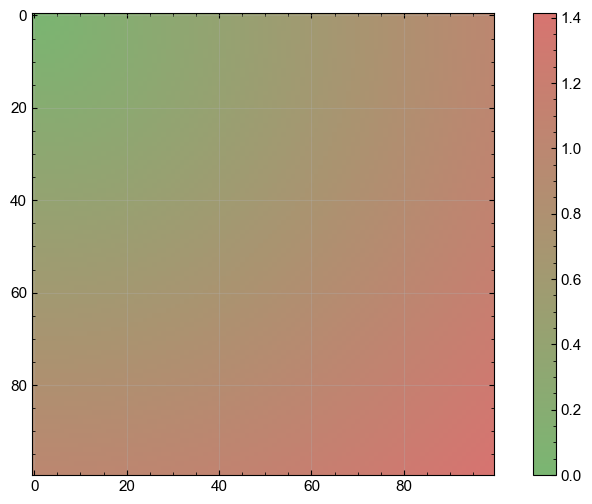

In [ ]:
import matplotlib.colors as mcolors

cmap = mcolors.LinearSegmentedColormap.from_list(
    "green_to_red_muted",
    ["#7AB672", "#D77470"],
    N=256
)


x,y = np.meshgrid(np.linspace(0,1,100), np.linspace(0,1,100))
data = np.sqrt(x**2 + y**2)
plt.imshow(data, cmap=cmap); plt.colorbar()

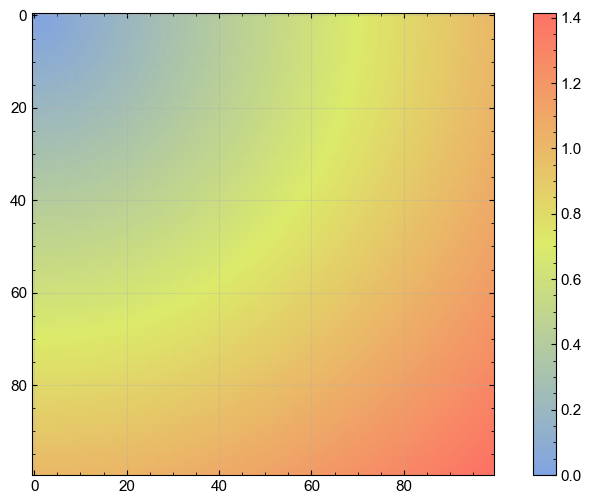

In [44]:
import numpy as np
import matplotlib.colors as mcolors

def muted_coldhot(c0="#81A3E2", c1="#FE7265", mid="#DCEB6A", N=256):
    # mid is a muted warm tan (helps the perceptual "warming" in the center)
    return mcolors.LinearSegmentedColormap.from_list(
        "muted_coldhot", [c0, mid, c1], N=N
    )

cmap = muted_coldhot()
x,y = np.meshgrid(np.linspace(0,1,100), np.linspace(0,1,100))
data = np.sqrt(x**2 + y**2)
plt.imshow(data, cmap=cmap); plt.colorbar()